# Imports and Data

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from utils.BayesClassifier import Binary, BinaryMVG, BinaryNaiveBayes, BinaryTiedVariance
from utils.BinaryLR import BinaryLR
from utils.SVM import SVM
from utils.utils import evaluate_model, load_data, split_db_2to1, vcol, vrow, get_cov, get_PCs, loglikelihood, logpdf_GAU_ND

In [2]:
PROJECT_FILE = "../data/trainData.txt"
D, L, labels = load_data(PROJECT_FILE)
feature_names = [f'F{i}' for i in range(0, D.shape[0])]
L = L.astype(int)
labels = [0, 1]
(DTR, LTR), (DTE, LTE) = split_db_2to1(D, L)

P = get_PCs(DTR, 3)
DTR_PCA = P.T @ DTR
DTE_PCA = P.T @ DTE

# Gaussian Fits

We try to fit a gaussian to each feature individually

![gaussian_fits](./results/gaussian_fits.png)

0 | -22208.396911800235
0 | F0 | -3401.1592128380944
0 | F1 | -4767.769396180696
0 | F2 | -3348.7974460431906
0 | F3 | -3310.431628254144
0 | F4 | -3666.2226018240754
0 | F5 | -3720.119295268737
1 | -24337.94149419995
1 | F0 | -4809.550701238997
1 | F1 | -3446.7154357258905
1 | F2 | -3368.2544258158905
1 | F3 | -3380.379592940937
1 | F4 | -4686.293683041351
1 | F5 | -4650.767954052914


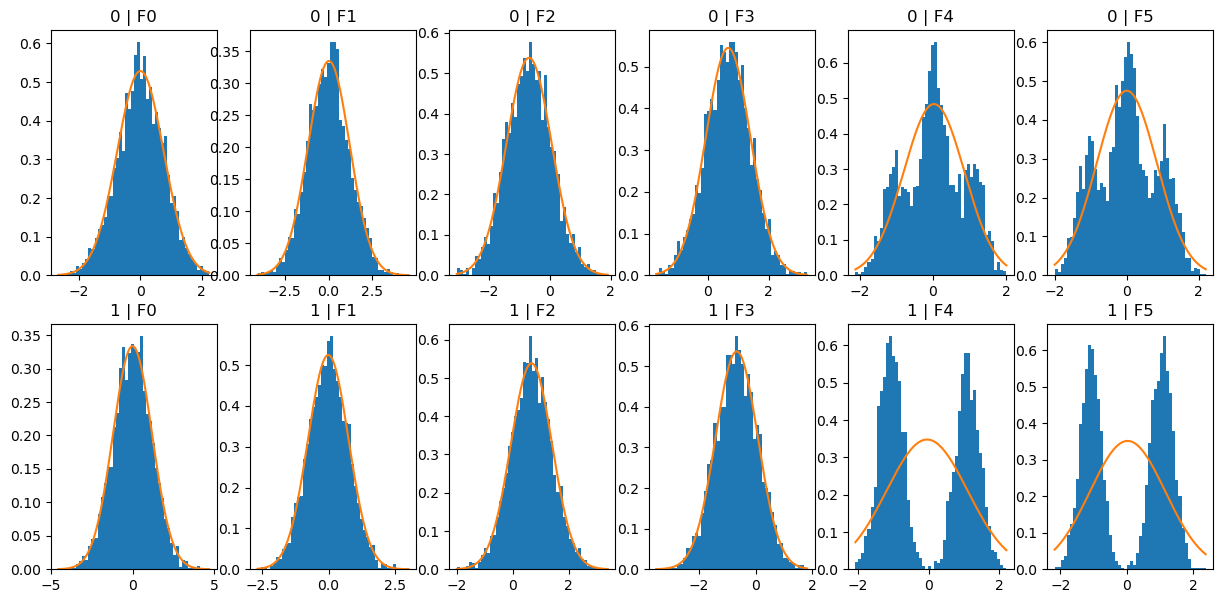

In [ ]:
plt.figure(figsize=(15, 7))

plots_rows = len(labels)
plots_cols = D.shape[0]

for i, l in enumerate(labels):
    class_data = D[:,L==l]

    u_ML = vcol(class_data.mean(1))
    C_ML = get_cov(class_data)

    class_ll = loglikelihood(class_data, u_ML, C_ML)
    print(f"{l} | {class_ll}")


    j=0
    for feature in class_data:
        feature = vrow(feature)
        u_ML = feature.mean(1)
        C_ML = get_cov(feature)
        feature_ll = loglikelihood(feature, u_ML, C_ML)
        print(f"{l} | {feature_names[j]} | {feature_ll}")

        XPlot = np.linspace(feature.min(), feature.max(), 1000)
        logpdf_plot = logpdf_GAU_ND(vrow(XPlot), u_ML, C_ML)

        plt.subplot(plots_rows, plots_cols, i*plots_cols + j + 1)
        plt.hist(feature.ravel(), bins=50, density=True)
        plt.plot(XPlot.ravel(), np.exp(logpdf_plot.ravel()))

        plt.title(f"{l} | {feature_names[j]}")

        j+=1


# Gaussian Models

Last lab, we fit a gaussian to each individual feature. It seems features 4 and 5 are not gaussian, so lets analyze the performance without them.

Besides, in 1st lab we saw that features 0|1 have similar mean and different variance, while 2|3 have similar variance but different mean. Lets analyze the performance using only a pair.

Finally, lets try applying PCS  to the data and see the results

| | MVG | Tied | NB |
| -----| --- | ---- | --- |
| All Features | 7% | 9.3% | 7.2% |
| 0, 1, 2, 3 | 7.4% | 9.4% | 7.5% |
| 0, 1 | 36% | 50% | 36% |
| 2, 3 | 9.5% | 9.5% | 9.5% |
| PCA | 8.9% | 9.3% | 9% |

## Models

In [ ]:
mvg = BinaryMVG()
nb = BinaryNaiveBayes()
tv = BinaryTiedVariance()

In [ ]:
Pc = np.ones((2,1))/2
mvg.set_priors(Pc)
nb.set_priors(Pc)
tv.set_priors(Pc)

costs = np.array([
    [0, 1],
    [1, 0]
])

mvg.set_cost_matrix(costs)
nb.set_cost_matrix(costs)
tv.set_cost_matrix(costs)

mvg.set_threshold_via_prior_ratio()
nb.set_threshold_via_prior_ratio()

## All Features

In [ ]:
mvg.fit(DTR, LTR)
nb.fit(DTR, LTR)
tv.fit(DTR, LTR)

In [ ]:
mvg.predict(DTE)
nb.predict(DTE)
tv.predict(DTE)

In [ ]:
print("MVG: ", f"{mvg.evaluate(LTE)[0]:.4f}")
print("Naive Bayes: ", f"{nb.evaluate(LTE)[0]:.4f}")
print("Tied Variance: ", f"{tv.evaluate(LTE)[0]:.4f}")

MVG:  0.0700
Naive Bayes:  0.0720
Tied Variance:  0.0930


### Investigating Feature Independence

Investigating the features, we found low correlation between features, making their independence assumption likely true. That allows the Naive Bayes Classifier to work properly

In [ ]:
c0 = get_cov(DTR[:, LTR==0])
c1 = get_cov(DTR[:, LTR==1])

In [ ]:
print(c0, "\n\n", c1)

[[ 6.01e-01  5.16e-05  1.91e-02  1.93e-02  1.28e-02 -1.35e-02]
 [ 5.16e-05  1.45e+00 -1.61e-02 -1.59e-02 -2.65e-02  2.29e-02]
 [ 1.91e-02 -1.61e-02  5.65e-01 -1.84e-03 -6.91e-03  1.69e-02]
 [ 1.93e-02 -1.59e-02 -1.84e-03  5.42e-01  5.25e-03  1.36e-02]
 [ 1.28e-02 -2.65e-02 -6.91e-03  5.25e-03  6.96e-01  1.58e-02]
 [-1.35e-02  2.29e-02  1.69e-02  1.36e-02  1.58e-02  6.87e-01]] 

 [[ 1.45e+00 -1.47e-02  5.57e-03  1.57e-02  1.95e-02 -1.77e-04]
 [-1.47e-02  5.53e-01 -1.12e-02 -9.06e-03 -1.47e-02  1.63e-02]
 [ 5.57e-03 -1.12e-02  5.57e-01  2.76e-02 -3.77e-03 -1.46e-02]
 [ 1.57e-02 -9.06e-03  2.76e-02  5.70e-01 -1.17e-02  3.50e-02]
 [ 1.95e-02 -1.47e-02 -3.77e-03 -1.17e-02  1.34e+00  1.69e-02]
 [-1.77e-04  1.63e-02 -1.46e-02  3.50e-02  1.69e-02  1.30e+00]]


In [ ]:
Corr0 = c0 / ( vcol(c0.diagonal()**0.5) * vrow(c0.diagonal()**0.5) )
Corr1 = c1 / ( vcol(c1.diagonal()**0.5) * vrow(c1.diagonal()**0.5) )

print(Corr0, "\n\n", Corr1)

[[ 1.00e+00  5.53e-05  3.27e-02  3.37e-02  1.98e-02 -2.10e-02]
 [ 5.53e-05  1.00e+00 -1.78e-02 -1.79e-02 -2.64e-02  2.30e-02]
 [ 3.27e-02 -1.78e-02  1.00e+00 -3.33e-03 -1.10e-02  2.71e-02]
 [ 3.37e-02 -1.79e-02 -3.33e-03  1.00e+00  8.55e-03  2.23e-02]
 [ 1.98e-02 -2.64e-02 -1.10e-02  8.55e-03  1.00e+00  2.29e-02]
 [-2.10e-02  2.30e-02  2.71e-02  2.23e-02  2.29e-02  1.00e+00]] 

 [[ 1.00e+00 -1.64e-02  6.20e-03  1.73e-02  1.40e-02 -1.29e-04]
 [-1.64e-02  1.00e+00 -2.02e-02 -1.61e-02 -1.70e-02  1.92e-02]
 [ 6.20e-03 -2.02e-02  1.00e+00  4.89e-02 -4.36e-03 -1.71e-02]
 [ 1.73e-02 -1.61e-02  4.89e-02  1.00e+00 -1.34e-02  4.06e-02]
 [ 1.40e-02 -1.70e-02 -4.36e-03 -1.34e-02  1.00e+00  1.28e-02]
 [-1.29e-04  1.92e-02 -1.71e-02  4.06e-02  1.28e-02  1.00e+00]]


## Selecting Features

In [ ]:
D, L, labels = load_data(PROJECT_FILE)
D = D[4:6, :]
L = L.astype(int)

(DTR, LTR), (DTE, LTE) = split_db_2to1(D, L)

In [ ]:
mvg.fit(DTR, LTR)
nb.fit(DTR, LTR)
tv.fit(DTR, LTR)


In [ ]:
mvg.predict(DTE)
nb.predict(DTE)
tv.predict(DTE)

In [ ]:
print("MVG: ", f"{mvg.evaluate(LTE)[0]:.4f}")
print("Naive Bayes: ", f"{nb.evaluate(LTE)[0]:.4f}")
print("Tied Variance: ", f"{tv.evaluate(LTE)[0]:.4f}")

MVG:  0.2710
Naive Bayes:  0.2620
Tied Variance:  0.4895


## Including PCA

In [ ]:
mvg.fit(DTR_PCA, LTR)
nb.fit(DTR_PCA, LTR)
tv.fit(DTR_PCA, LTR)

In [ ]:
mvg.predict(DTE_PCA)
nb.predict(DTE_PCA)
tv.predict(DTE_PCA)

In [ ]:

print("MVG: ", f"{mvg.evaluate(LTE):.4f}")
print("Naive Bayes: ", f"{nb.evaluate(LTE):.4f}")
print("Tied Variance: ", f"{tv.evaluate(LTE):.4f}")

# Optimal Bayes Decision

Varying Effective priors on the data to investigate performance

- **DCF**

| model \ Effective Prior | 0.1 | 0.5 | 0.9 |
| ----- | ---- | ----| ---- |
| MVG | 0.305 | 0.140 | 0.400 |
| NB | 0.302 | 0.144 | 0.389 |
| TV | 0.406 | 0.186 | 0.463 |

- **MinDCF**

| model \ Effective Prior | 0.1 | 0.5 | 0.9 |
| ----- | ---- | ----| ---- |
| MVG | 0.263 | 0.130 | 0.342 |
| NB | 0.257 | 0.131 | 0.351 |
| TV | 0.363 | 0.181 | 0.442 |

<br>

![DCFs_GM](./results/DCFs_GaussianModels.png)

## Models

In [3]:
mvg = BinaryMVG()
nb = BinaryNaiveBayes()
tv = BinaryTiedVariance()

In [4]:
costs = np.array([
    [0, 1],
    [1, 0]
])

mvg.fit(DTR, LTR)
nb.fit(DTR, LTR)
tv.fit(DTR, LTR)

costs = np.array([
    [0, 1],
    [1, 0]
])

mvg.set_cost_matrix(costs)
nb.set_cost_matrix(costs)
tv.set_cost_matrix(costs)

## Vary Effective Priors

In [ ]:
def calc_eff_prior(p, Cfn, Cfp): 
    return (p*Cfn) / (p*Cfn + (1-p)*Cfp)

effP = [
    calc_eff_prior(0.5, 1, 1),
    calc_eff_prior(0.9, 1, 1),
    calc_eff_prior(0.1, 1, 1),
    calc_eff_prior(0.5, 1, 9),
    calc_eff_prior(0.5, 9, 1)
]
print(effP)

In [ ]:
for p in effP:
    mvg.set_priors(vcol(np.array([(1-p), p])))
    mvg.set_optimal_thresold()
    mvg.predict(DTE)
    err, cm, DCFu, DCF = mvg.evaluate(LTE)
    print("Effective Prior: ", p)
    print(cm)
    print("DCF: ", DCF)
    print("\n")

In [ ]:
ep = 0.9

tv.set_priors(vcol(np.array([(1-ep), ep])))
tv.set_optimal_thresold()
tv.predict(DTE)
err, cm, DCFu, DCF = tv.evaluate(LTE)
minDCF = tv.calc_minDCF(LTE)
print(f"DCF: {DCF: .3f}")
print(f"minDCF: {minDCF: .3f}")

## Plots

In [5]:
effPriorLogOdds = np.linspace(-4, 4, 21)
effPi = 1/(1+np.exp(-effPriorLogOdds))

In [6]:
DCFs_mvg = []
minDCFs_mvg = []

DCFs_nb = []
minDCFs_nb = []

DCFs_tv = []
minDCFs_tv = []

for pi in effPi:
    mvg.set_priors(vcol(np.array([(1-pi), pi])))
    mvg.set_optimal_thresold()
    mvg.predict(DTE)
    err, cm, DCFu, DCF = mvg.evaluate(LTE)
    DCFs_mvg.append(DCF)
    minDCFs_mvg.append(mvg.calc_minDCF(LTE))

    nb.set_priors(vcol(np.array([(1-pi), pi])))
    nb.set_optimal_thresold()
    nb.predict(DTE)
    err, cm, DCFu, DCF = nb.evaluate(LTE)
    DCFs_nb.append(DCF)
    minDCFs_nb.append(nb.calc_minDCF(LTE))

    tv.set_priors(vcol(np.array([(1-pi), pi])))
    tv.set_optimal_thresold()
    tv.predict(DTE)
    err, cm, DCFu, DCF = tv.evaluate(LTE)
    DCFs_tv.append(DCF)
    minDCFs_tv.append(tv.calc_minDCF(LTE))


DCFs_mvg = np.array(DCFs_mvg)
minDCFs_mvg = np.array(minDCFs_mvg)

DCFs_nb = np.array(DCFs_nb)
minDCFs_nb = np.array(minDCFs_nb)

DCFs_tv = np.array(DCFs_tv)
minDCFs_tv = np.array(minDCFs_tv)

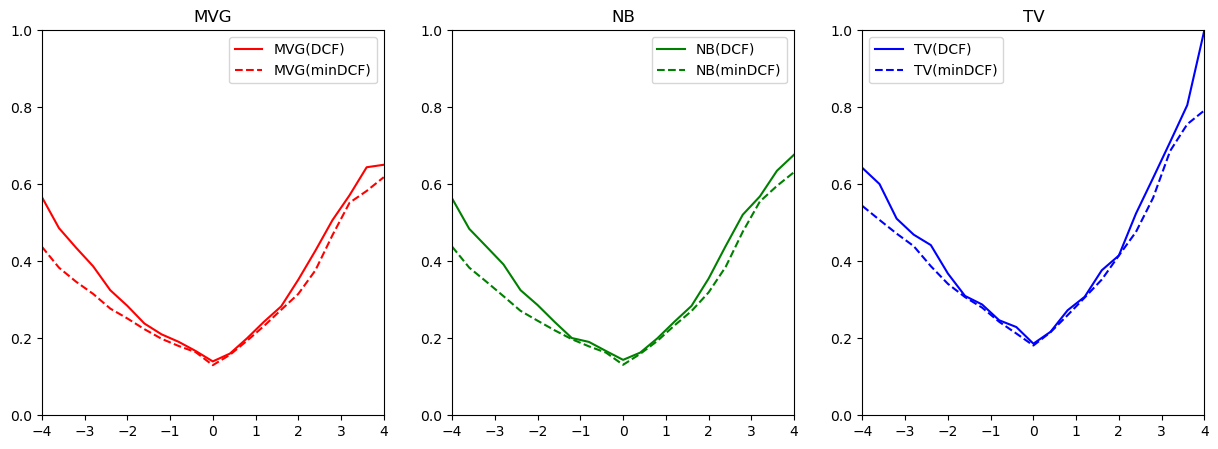

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].set_title("MVG")
ax[1].set_title("NB")
ax[2].set_title("TV")

ax[0].plot(effPriorLogOdds, DCFs_mvg, label="MVG(DCF)", color="r")
ax[0].plot(effPriorLogOdds, minDCFs_mvg, label="MVG(minDCF)", color="r", ls="--")
ax[1].plot(effPriorLogOdds, DCFs_nb, label="NB(DCF)", color="g")
ax[1].plot(effPriorLogOdds, minDCFs_nb, label="NB(minDCF)", color="g", ls="--")
ax[2].plot(effPriorLogOdds, DCFs_tv, label="TV(DCF)", color="b")
ax[2].plot(effPriorLogOdds, minDCFs_tv, label="TV(minDCF)", color="b", ls="--")
ax[0].set_ylim([0, 1])
ax[0].set_xlim([-4, 4])
ax[1].set_ylim([0, 1])
ax[1].set_xlim([-4, 4])
ax[2].set_ylim([0, 1])
ax[2].set_xlim([-4, 4])
ax[0].legend()
ax[1].legend()
ax[2].legend()
plt.show()

# Logistic Regression

![DCFs_LR](./results/DCFs_LR.png)

In [10]:
lr = BinaryLR(pi1=0.1)

In [11]:
lamb = np.logspace(-4, 2, 13)

## All data

In [12]:

DCFs_allData = np.zeros(len(lamb))
minDCFs_allData = np.zeros(len(lamb))
for i, l in enumerate(lamb):
    lr.set_lambda(l)
    lr.fit(DTR, LTR)
    pred = lr.predict(DTE)
    DCF = lr.evaluate(LTE)[3]
    minDCF = lr.calc_minDCF(LTE)
    DCFs_allData[i] = DCF
    minDCFs_allData[i] = minDCF


## Partial Data

In [13]:

DCFs_50samples = np.zeros(len(lamb))
minDCFs_50samples = np.zeros(len(lamb))
for i, l in enumerate(lamb):
    lr.set_lambda(l)
    lr.fit(DTR[:, ::50], LTR[::50])
    pred = lr.predict(DTE)
    DCF = lr.evaluate(LTE)[3]
    minDCF = lr.calc_minDCF(LTE)
    DCFs_50samples[i] = DCF
    minDCFs_50samples[i] = minDCF


## Prior weighted

In [14]:

DCFs_pw = np.zeros(len(lamb))
minDCFs_pw = np.zeros(len(lamb))
for i, l in enumerate(lamb):
    lr.set_lambda(l)
    lr.fit(DTR, LTR, prior_weighted=True)
    pred = lr.predict(DTE)
    DCF = lr.evaluate(LTE)[3]
    minDCF = lr.calc_minDCF(LTE)
    DCFs_pw[i] = DCF
    minDCFs_pw[i] = minDCF


## Quadratic

In [15]:
# DTR shape: (D, N)
D, N = DTR.shape
quad_DTR = np.einsum('dn,en->den', DTR, DTR).reshape(D*D, N)  # (D², N)
quadratic_DTR = np.vstack((quad_DTR, DTR))                      # (D²+D, N)

quad_DTE = np.einsum('dn,en->den', DTE, DTE).reshape(D*D, DTE.shape[1])
quadratic_DTE = np.vstack((quad_DTE, DTE))


## Plots

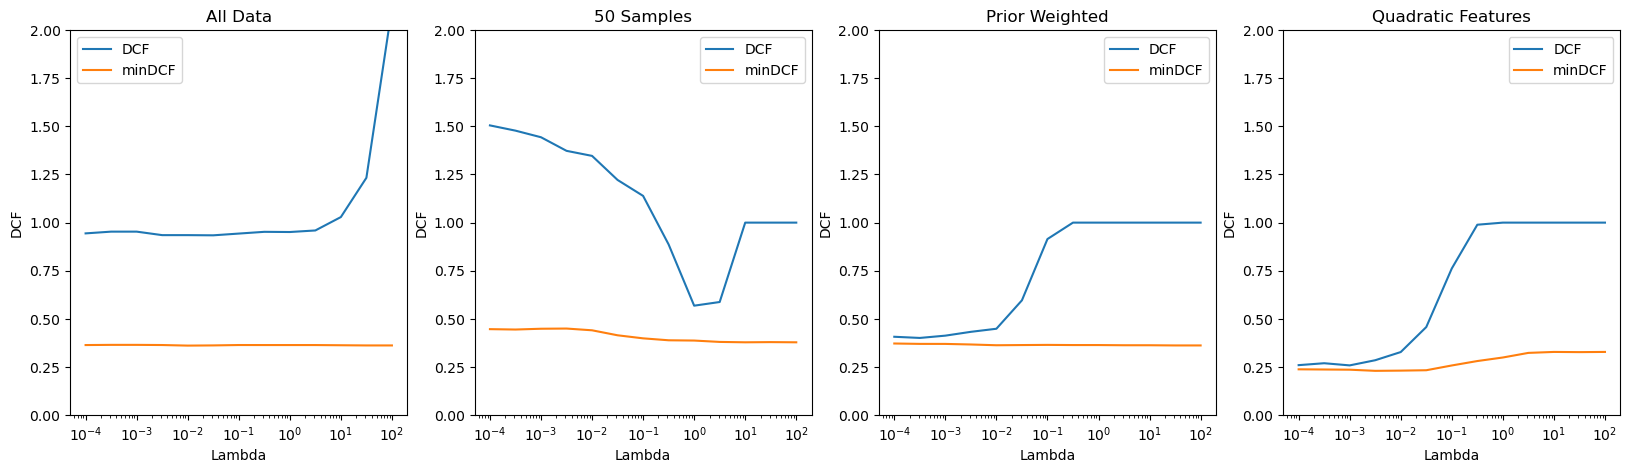

In [20]:
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].plot(lamb, DCFs_allData, label='DCF')
ax[0].plot(lamb, minDCFs_allData, label='minDCF')
ax[0].set_xscale('log', base=10)
ax[0].set_ylim([0, 2])
ax[0].set_xlabel('Lambda')
ax[0].set_ylabel('DCF')
ax[0].set_title('All Data')
ax[0].legend()

ax[1].plot(lamb, DCFs_50samples, label='DCF')
ax[1].plot(lamb, minDCFs_50samples, label='minDCF')
ax[1].set_xscale('log', base=10)
ax[1].set_ylim([0, 2])
ax[1].set_xlabel('Lambda')
ax[1].set_ylabel('DCF')
ax[1].set_title('50 Samples')
ax[1].legend() 

ax[2].plot(lamb, DCFs_pw, label='DCF')
ax[2].plot(lamb, minDCFs_pw, label='minDCF')
ax[2].set_xscale('log', base=10)
ax[2].set_ylim([0, 2])
ax[2].set_xlabel('Lambda')
ax[2].set_ylabel('DCF')
ax[2].set_title('Prior Weighted')
ax[2].legend()

ax[3].plot(lamb, DCFs_quadratic, label='DCF')
ax[3].plot(lamb, minDCFs_quadratic, label='minDCF')
ax[3].set_xscale('log', base=10)
ax[3].set_ylim([0, 2])
ax[3].set_xlabel('Lambda')
ax[3].set_ylabel('DCF')
ax[3].set_title('Quadratic Features')
ax[3].legend()
plt.show()


# SVM

## Linear

In [ ]:
svm = SVM(K=1, kernel='linear')

In [4]:
C_values = np.logspace(-5, 0, 11)

DCFs = np.zeros(len(C_values))
minDCFs = np.zeros(len(C_values))
for i, C in enumerate(C_values):
    svm.C = C
    svm.fit(DTR[:, ::50], LTR[::50])
    pred = svm.predict(DTE)
    DCF = svm.evaluate(LTE)[3]
    minDCF = svm.calc_minDCF(LTE)
    DCFs[i] = DCF
    minDCFs[i] = minDCF

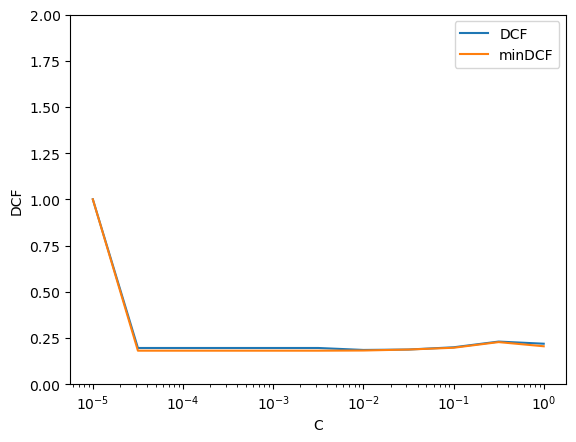

In [7]:
plt.plot(C_values, DCFs, label='DCF')
plt.plot(C_values, minDCFs, label='minDCF')
plt.xscale('log', base=10)
plt.ylim([0, 2])
plt.xlabel('C')
plt.ylabel('DCF')
plt.legend()

## Polynomial

In [ ]:
svm = SVM(kernel='polynomial', K=0)

In [ ]:
C_values = np.logspace(-5, 0, 11)


DCFs = np.zeros(len(C_values))
minDCFs = np.zeros(len(C_values))
for i, C in enumerate(C_values):
    svm.C = C
    svm.fit(DTR[:, ::50], LTR[::50])
    pred = svm.predict(DTE)
    DCF = svm.evaluate(LTE)[3]
    minDCF = svm.calc_minDCF(LTE)
    DCFs[i] = DCF
    minDCFs[i] = minDCF

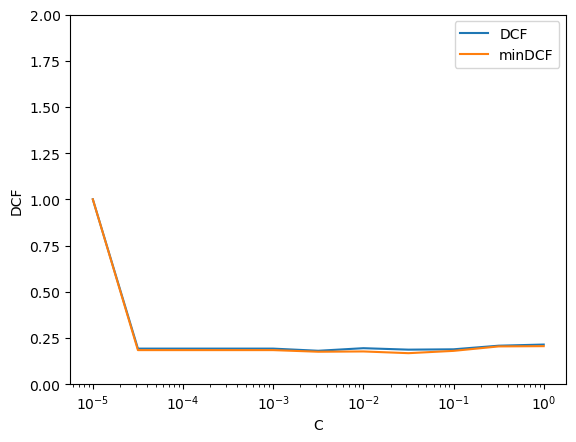

In [5]:
plt.plot(C_values, DCFs, label='DCF')
plt.plot(C_values, minDCFs, label='minDCF')
plt.xscale('log', base=10)
plt.ylim([0, 2])
plt.xlabel('C')
plt.ylabel('DCF')
plt.legend()

## RBF

In [7]:
svm = SVM(kernel='rbf', K = 0)

In [8]:
C_values = np.logspace(-3, 2, 11)
gamma_values = [np.exp(-4), np.exp(-3), np.exp(-2), np.exp(-1)]

DCFs = np.zeros((len(C_values), len(gamma_values)))
minDCFs = np.zeros((len(C_values), len(gamma_values)))
for i, C in enumerate(C_values):
    for j, gamma in enumerate(gamma_values):
        svm.C = C
        svm.gamma = gamma
        svm.fit(DTR[:, ::50], LTR[::50])
        pred = svm.predict(DTE)
        DCF = svm.evaluate(LTE)[3]
        minDCF = svm.calc_minDCF(LTE)
        DCFs[i, j] = DCF
        minDCFs[i, j] = minDCF

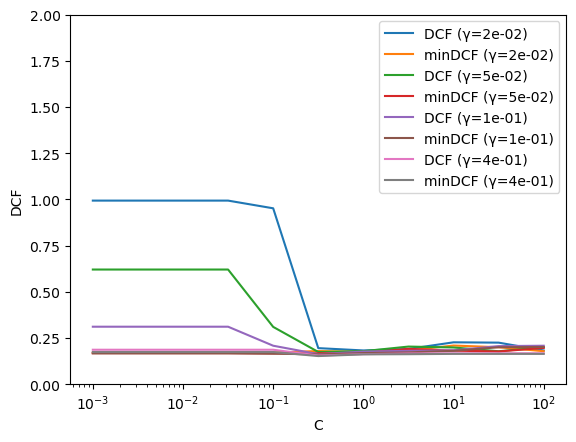

In [9]:
for j, gamma in enumerate(gamma_values):
    plt.plot(C_values, DCFs[:, j], label=f'DCF (γ={gamma:.0e})')
    plt.plot(C_values, minDCFs[:, j], label=f'minDCF (γ={gamma:.0e})')
plt.xscale('log', base=10)
plt.ylim([0, 2])
plt.xlabel('C')
plt.ylabel('DCF')
plt.legend()